# Proyecto 02:  K-Means y PCA
--- 
Laurie C. Hernández Pacheco - A01286569  
Emilio A. González Huerta - A01286440  
Fernando Álvarez Ruiz - A01286754  

En esta libreta, se trabaja con la implementación de K-Means, donde se entrenan diferentes modelos para varios valores de `K` usando el dataset `customer_segmentation`, un dataset enfocado a la segmentación de clientes. La descripción de cada columna del dataset se encuentra a continuación: 

| Nombre | Tipo | Descripción |
|------|------|------------|
| Id | int | Identificador único para cada individuo en el dataset. |
| Year_Birth | int | Año de nacimiento del individuo. |
| Education | string | Nivel más alto de educación alcanzado por el individuo. |
| Marital_Status | string | Estado civil del individuo. |
| Income | float | Ingreso anual del individuo. |
| Kidhome | int | Número de niños pequeños en el hogar. |
| Teenhome | int | Número de adolescentes en el hogar. |
| Dt_Customer | datetime | Fecha en la que el cliente se registró o ingresó a la base de datos. |
| Recency | int | Número de días desde la última compra o interacción. |
| MntWines | float | Cantidad de dinero gastada en vinos. |
| MntFruits | float | Cantidad de dinero gastada en frutas. |
| MntMeatProducts | float | Cantidad de dinero gastada en productos cárnicos. |
| MntFishProducts | float | Cantidad de dinero gastada en productos de pescado. |
| MntSweetProducts | float | Cantidad de dinero gastada en productos dulces. |
| MntGoldProds | float | Cantidad de dinero gastada en productos de lujo (gold). |
| NumDealsPurchases | int | Número de compras realizadas con descuento o promoción. |
| NumWebPurchases | int | Número de compras realizadas a través del sitio web. |
| NumCatalogPurchases | int | Número de compras realizadas mediante catálogos. |
| NumStorePurchases | int | Número de compras realizadas en tiendas físicas. |
| NumWebVisitsMonth | int | Número de visitas al sitio web en un mes. |
| AcceptedCmp3 | (binaria) | Indica si aceptó la tercera campaña de marketing (1 = sí, 0 = no). |
| AcceptedCmp4 | (binaria) | Indica si aceptó la cuarta campaña de marketing (1 = sí, 0 = no). |
| AcceptedCmp5 | (binaria) | Indica si aceptó la quinta campaña de marketing (1 = sí, 0 = no). |
| AcceptedCmp1 | (binaria) | Indica si aceptó la primera campaña de marketing (1 = sí, 0 = no). |
| AcceptedCmp2 | (binaria) | Indica si aceptó la segunda campaña de marketing (1 = sí, 0 = no). |
| Complain | (binaria) | Indica si el individuo ha presentado una queja (1 = sí, 0 = no). |
| Z_CostContact | float | Costo constante asociado a contactar a un cliente. |
| Z_Revenue | float | Ingreso constante asociado a una respuesta exitosa de campaña. |
| Response | (binaria) | Indica si el individuo respondió a la campaña de marketing (1 = sí, 0 = no). |


De cada entrenamiento, se determina el valor adecuado de `K` usando la técnica del codo y la técnica de la silueta.  

Para comparar el resultado de la implementación manual de K-Means, se utiliza la librería de `scikit-learn` con la `K` siendo el valor determinado utilizando las técnicas mencionadas.  

Además, dado que los datos cuentan con más de 3 dimensiones, se aplica PCA con la librería `libreria` para obtener datos en 2D y 3D. Se grafican los resultados del modelo de K-Means para los datos una vez aplicado el PCA para visualizar los datos de cada cluster. 

## 0. Setup 

Inicialmente, se importan las siguientes librerías:
* `numpy`: se utiliza para operaciones matemáticas y manipulación de arreglos numéricos multidimensionales, como el cálculo de distancias euclidianas, promedios de centroides y generación de índices aleatorios en la implementación manual de K-Means.

* `matplotlib.pyplot`: se utiliza para generar visualizaciones estáticas como las gráficas del método del codo, el coeficiente de silueta y los scatter plots 2D de los clusters proyectados con PCA.

* `sklearn.datasets.make_blobs`: se utiliza para generar datos sintéticos con distribución gaussiana agrupada, usado para probar y validar la implementación manual de K-Means antes de aplicarla al dataset real.

* `pandas`: se utiliza para la carga, exploración y manipulación del dataset `customer_segmentation.csv`, incluyendo el manejo de valores nulos, eliminación de duplicados y creación de nuevas features como `Total_Spending`, `Children` y `Age`.

* `sklearn.preprocessing.LabelEncoder`: se utiliza para convertir las etiquetas de texto de los true labels (e.g., `"Higher Education"`, `"Low Education"`, `"Postgraduate"`) en valores numéricos para su uso en métricas de evaluación.

* `sklearn.preprocessing.StandardScaler`: se utiliza para estandarizar las features del dataset, transformándolas a media 0 y desviación estándar 1, condición necesaria para que K-Means no se vea sesgado por diferencias de escala entre variables.

* `sklearn.cluster.KMeans`: se utiliza como implementación de referencia de K-Means de la librería Scikit-learn, para comparar resultados contra la implementación manual en términos de SSE, coeficiente de silueta y asignación de clusters.

* `sklearn.metrics.silhouette_score`: se utiliza para calcular el coeficiente de silueta de los modelos entrenados con Scikit-learn, métrica que evalúa qué tan bien separados están los clusters para cada valor de K.

* `sklearn.decomposition.PCA`: se utiliza para aplicar Análisis de Componentes Principales y reducir la dimensionalidad del dataset de 6 dimensiones a 2D y 3D, permitiendo visualizar la estructura de los clusters en espacios de menor dimensión.

* `mpl_toolkits.mplot3d.Axes3D`: se utiliza para habilitar la proyección tridimensional en figuras de Matplotlib, necesaria para renderizar los scatter plots 3D estáticos de los clusters sobre los componentes principales PC1, PC2 y PC3.

* `plotly.graph_objects`: se utiliza para generar las visualizaciones 3D interactivas de los clusters, permitiendo rotar los ejes, hacer zoom y explorar los puntos con el cursor directamente desde la notebook.

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 
import plotly.graph_objects as go

## 1. Implementación Manual de K-Means

Los pasos para hacer un k-means son los siguientes: 
1. Se inicializan los centros de cada cluster de manera aleatoria.
2. Se asigna cada punto de datos al cluster cuyo centroide esté más cercano (según una medida de distancia, comúnmente la distancia euclidiana).
3. Se actualizan los centros de los clusters recalculando el promedio (media) de todos los puntos asignados a cada cluster.
4. Se repiten los pasos 2 y 3 hasta que el modelo converge (es decir, cuando los centroides ya no cambian significativamente o las asignaciones se estabilizan).

Para encontrar los centroides más cercanos y en general para el cálculo de distancia se hace uso de la **distancia euclideana**, que se basa en la siguiente fórmula: 

$$
d(p,q) = \sqrt{\sum (p_i-q_i)^2}
$$
Donde $p$ y $q$ son dos puntos. 

In [274]:
def euclidean_dist(x1,x2): 
    return np.sqrt(np.sum((x1-x2)**2))

class KMeans_Manual: 
    def __init__(self, K=5,max_iters=100, plot_steps=False): 
        """
        K = cantidad de clusters en las que vamos a dividir
        max_iters: número máximo de iteraciones que se harán 
        plot_steps: para plottear los pasos de los centroides y labels. 
        """

        self.K=K
        self.max_iters=max_iters 
        self.plot_steps = plot_steps 

        # list of sample indices for each cluster 
        self.clusters = [[] for _ in range(self.K)]
        # para guardar los centroids (mean vector para cada cluster) 
        self.centroids = []
    
    def predict(self, X): 
        """ 
        X: numpy array con las features q vamos a usar 
        """
        # para kmeans no hay en sí un "fit", podemos llevar a cabo la predicción de una 
        self.X = X 
        self.n_samples, self.n_features = X.shape

        # empezamos eligiendo los centroides random
        random_sample_idxs = np.random.choice(self.n_samples, self.K, replace = False)
        self.centroids = [self.X[idx] for idx in random_sample_idxs]

        n_iter = 0
        for _ in range(self.max_iters): 
            # aquí vamos a ir asignand y repitiendo pasos 2 y 3 
            # empezamos creando una "helper function"
            self.clusters = self._create_clusters(self.centroids) 
            if(self.plot_steps): 
                self.plot(n_iter)
            n_iter+=1
            # calculamos los nuevos centroides con base en los clusters 
            centroids_old = self.centroids 
            self.centroids = self._get_centroids(self.clusters)

            # checamos si converge para ya acabar la función 
            if self._is_converged(centroids_old, self.centroids): 
                break

            if(self.plot_steps): 
                self.plot(n_iter)
        
        # aquí hacemoslo de relabelear los clusters
        return self._get_cluster_labels(self.clusters)

    def _get_cluster_labels(self, clusters): 

        #   cada sample recibe el label del cluster al que se le asignó 
        labels = np.empty(self.n_samples) 
        for cluster_idx, cluster in enumerate(clusters): 
            for sample_idx in cluster: 
                labels[sample_idx] = cluster_idx 
        
        return labels

    def _create_clusters(self, centroids): 
        # asignamos los samples a los centroides más cercanos 
        clusters = [[] for _ in range(self.K)]
        for idx, sample in enumerate(self.X): 
            centroid_idx = self._closest_centroid(sample, centroids)
            clusters[centroid_idx].append(idx) 
        return clusters  
    
    def _closest_centroid(self, sample, centroids): 
        # determinar la distancia del sample a cada centroide y sacar el que tiene la menor distancia
        distances = [euclidean_dist(sample, point) for point in centroids]
        closest_idx = np.argmin(distances) 
        return closest_idx 
    
    def _get_centroids(self, clusters): 
        # asignamos el valor medio de los clusters hacia los centroides
        centroids = np.zeros((self.K, self.n_features))
        for cluster_idx, cluster in enumerate(clusters): 
            if len(cluster) == 0:
                # reasignar un punto random como centroide
                centroids[cluster_idx] = self.X[np.random.randint(0, self.n_samples)]
            else:
                centroids[cluster_idx] = np.mean(self.X[cluster], axis=0)
        return centroids  

    def _is_converged(self, centroids_old, centroids):
        # aquí calculamos la distancia entre los centroides viejos y los nuevos para todos los centroides. si no hubo cambios en las distancias
        # (o casi no hubo cambios) podemos retornar True

        distances = [euclidean_dist(centroids_old[i], centroids[i]) for i in range(self.K)] 
        return sum(distances) < 1e-6

    def plot(self, n_iter=0): 
        fig, ax = plt.subplots(figsize =(8, 5))

        for i, index in enumerate(self.clusters): 
            point = self.X[index].T 
            ax.scatter(*point) 
        
        for point in self.centroids: 
            ax.scatter(*point, marker = "x", color = "black", linewidth=2)
        plt.title(f"KMeans | Iteración {n_iter}")
        plt.show()
    
    def _get_sse(self):
        # función para calcular inercia (SSE) 
        sse = 0
        for cluster_idx, cluster in enumerate(self.clusters):
            centroid = self.centroids[cluster_idx]
            for sample_idx in cluster:
                point = self.X[sample_idx]
                sse += np.sum((point - centroid) ** 2)
        return sse


Se prueba la implementación manual con `make_blobs`, una función de `scikit-learn`: 

(500, 2)
3


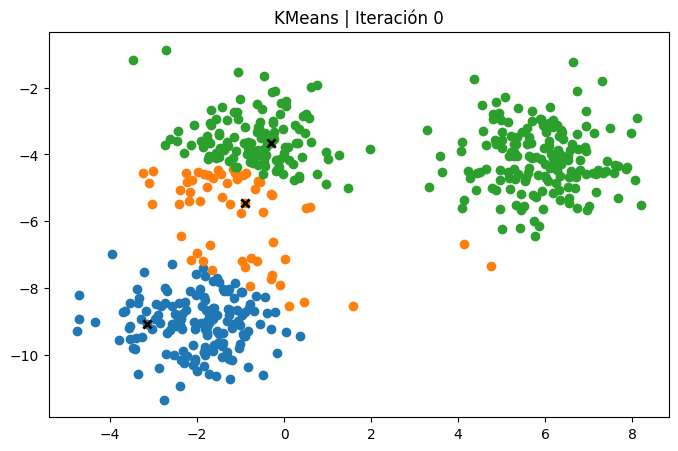

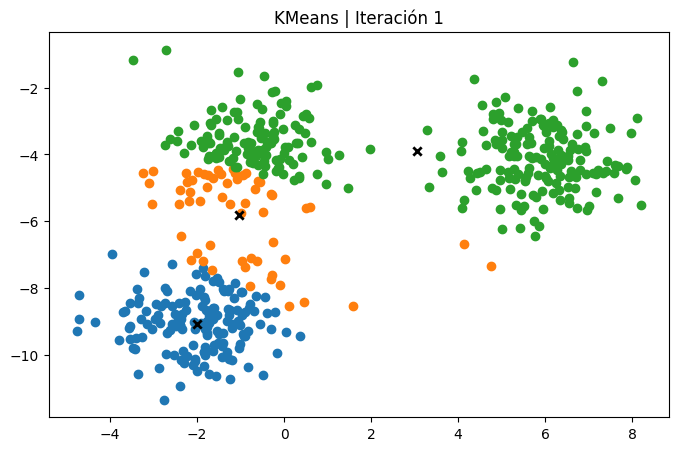

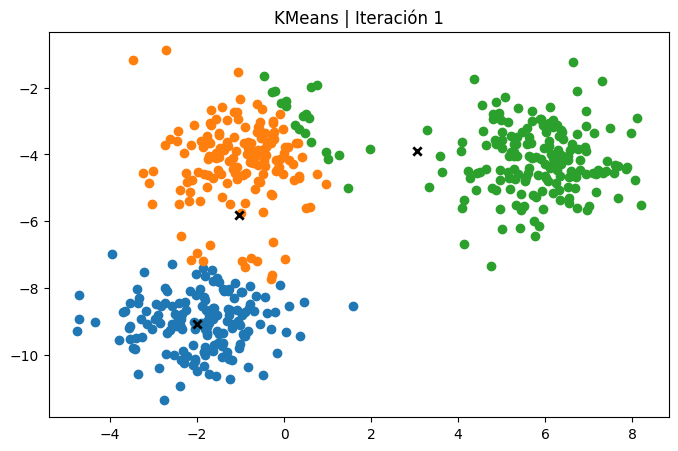

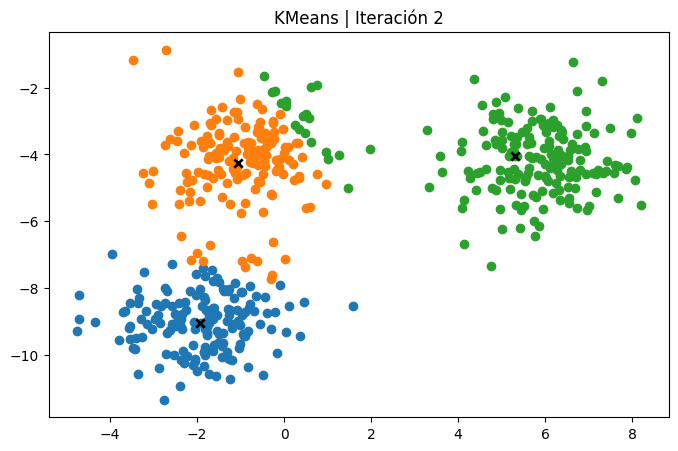

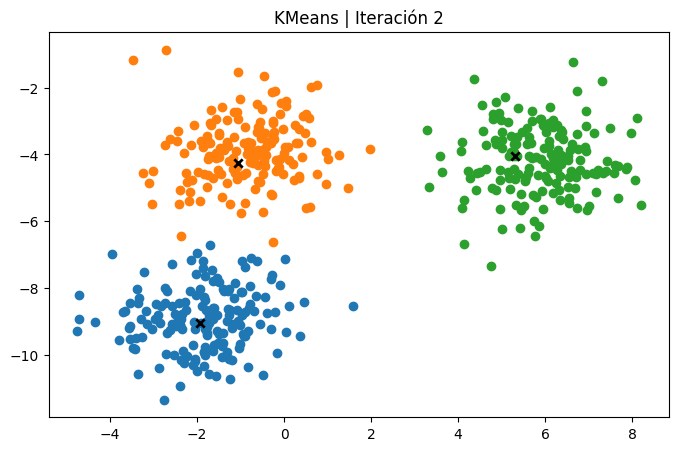

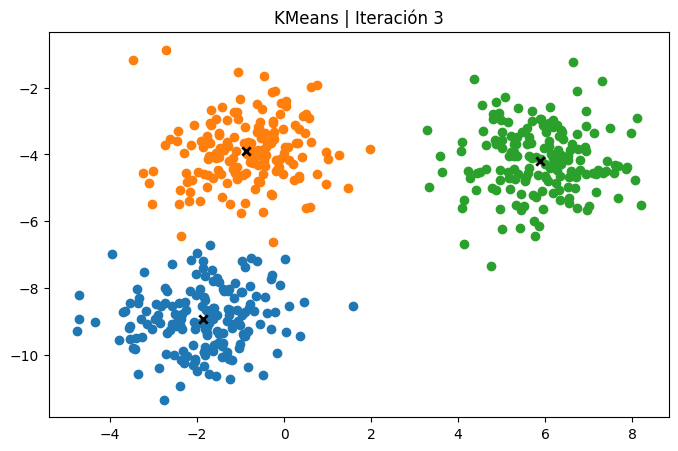

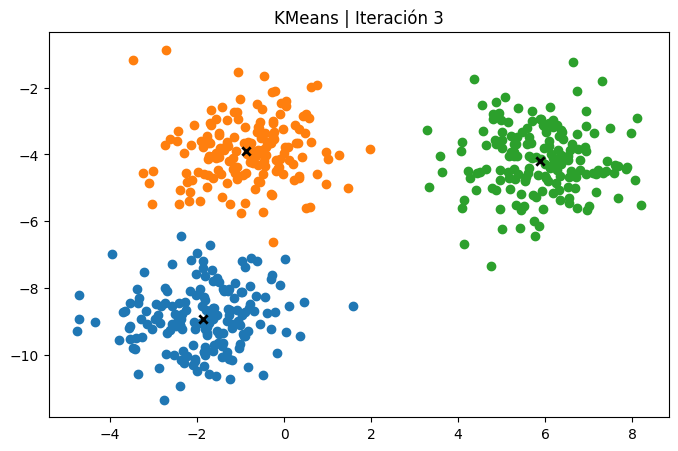

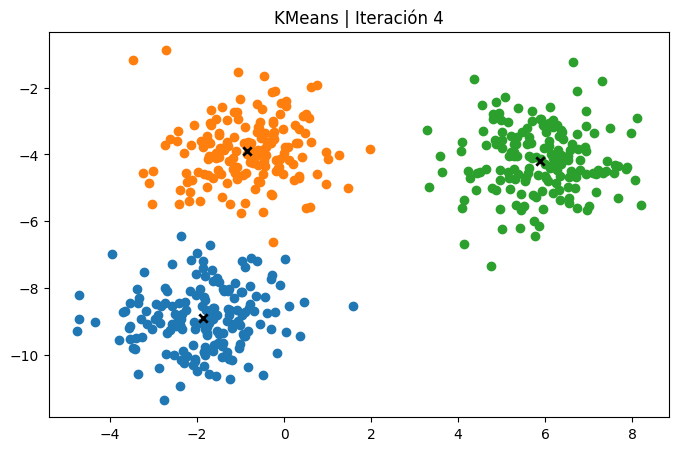

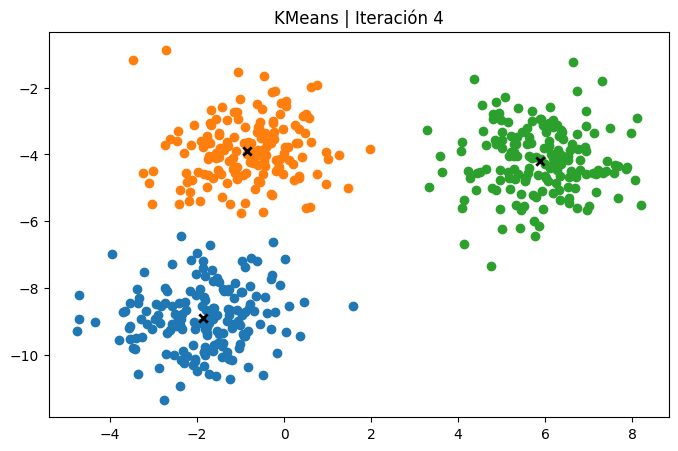

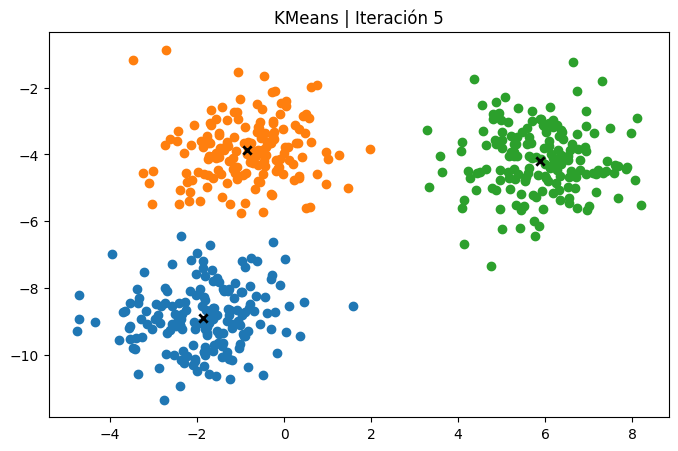

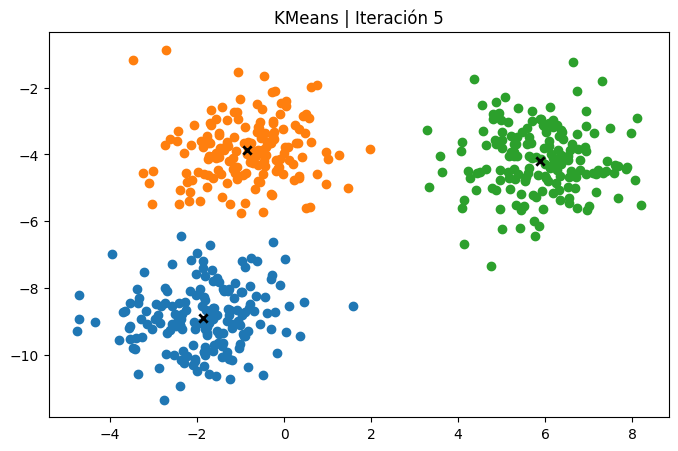

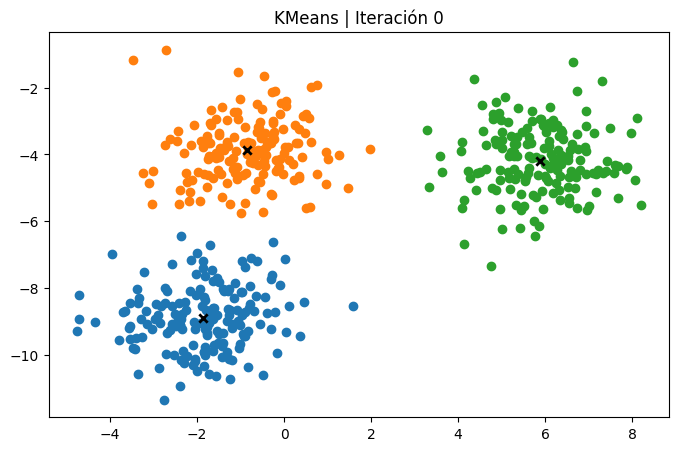

In [275]:
np.random.seed(42) 
X, y = make_blobs(
    centers = 3,
    n_samples= 500, 
    n_features = 2, 
    shuffle= True, 
    random_state= 40
)

print(X.shape)

clusters = len(np.unique(y))
print(clusters) 

k = KMeans_Manual(K=clusters, max_iters = 150, plot_steps=True)
y_pred = k.predict(X)

k.plot()


## 2. Exploración de Datos

En esta sección, se realiza la exploración de datos para el dataset `customer_segmentation.csv`. Se identifican la cantidad de nulos y se eliminan duplicados. 

In [276]:
df = pd.read_csv("customer_segmentation.csv")
print(f"Dimensiones del dataset: {df.shape}")

Dimensiones del dataset: (2240, 29)


In [277]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


Se identifican 2240 filas y 29 columnas del dataset, y se puede visualizar con `head(5)` las primeras 5 filas de los datos. Como se indicó en la tabla del inicio, la mayoría de los datos son numéricos con algunas columnas categóricas como `Education` y `Marital_Status`.  


A continuación se cuentan los NaNs:

In [278]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nPorcentaje de nulos:")
print(df.isnull().mean() * 100)

Valores nulos por columna:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Porcentaje de nulos:
ID                     0.000000
Year_Birth             0.000000
Education              0.000000
Marital_Status         0.000000
Income                 1.071429
Kidhome                0

Se identifican únicamente 24 NaNs en la columna `Income`. Debido a que únicamente forman parte de ~1% de los datos, se opta por eliminar por completo aquellas filas que contengan NaN. 

In [279]:
df = df.dropna()

A continuación, se elimina cualquier posible duplicado 

In [280]:
df = df.drop_duplicates()

Finalmente, se obtienen las nuevas dimensiones del dataframe: 

In [281]:
print(f"Dimensiones (sin NaNs ni duplicados):{df.shape}")

Dimensiones (sin NaNs ni duplicados):(2216, 29)


## 3. Selección de Features y Estandarización

En esta sección, se seleccionan ciertas features para realizar el clustering de los clientes, así como también una `true_label` para poder realizar una mejor comparativa del resultado del K-Means realizado.  
Inicialmente, se seleccionan las features a usar en el modelo. Dada la alta cantidad de columnas, se trabaja con los datos uniendo algunas que guardan relevancia y creando nuevas features que permiten seccionar mejor a los clientes

- Se combinan las features `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts` y `MntGoldProds` en la nueva columna `Total_Spending` que cuente el total de compras. 
- Se combinan las features `Kidhome` y `Teenhome` en `Children` para capturar la cantidad de menores de edad que existen en la casa. 
- Se hace una resta entre el año de `Dt_Customer` y `Year_Birth` para crear la nueva feature `Age`

In [282]:
# creación de columna total_spending
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

# creación de columna children
df["Children"] = df["Kidhome"] + df["Teenhome"]

# creación de columna age

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
df["Customer_Year"] = df["Dt_Customer"].dt.year
df["Age"] = df["Customer_Year"] - df["Year_Birth"]

A continuación, se describe cada una de estas nuevas columnas con el objetivo de detectar datos anormales o fuera de lo común.

In [283]:
df["Total_Spending"].describe()

count    2216.000000
mean      607.075361
std       602.900476
min         5.000000
25%        69.000000
50%       396.500000
75%      1048.000000
max      2525.000000
Name: Total_Spending, dtype: float64

In [284]:
df["Children"].describe()

count    2216.000000
mean        0.947202
std         0.749062
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         3.000000
Name: Children, dtype: float64

In [285]:
df["Age"].describe()

count    2216.000000
mean       44.208032
std        12.023812
min        16.000000
25%        36.000000
50%        43.000000
75%        54.000000
max       121.000000
Name: Age, dtype: float64

Se identifica en la columna `Age` edades de hasta 121. Este dato es poco realista y posiblemente se debe a un error de datos. Dado a que K-Means es sensible a este tipo de valores extremos, se determina que es necesario reducir la cantidad de datos, manteniendo únicamente aquellos que se encuentren dentro de un rango realista. 

In [286]:
q_low = df["Age"].quantile(0.01)
q_high = df["Age"].quantile(0.99)

df = df[(df["Age"] >= q_low) & (df["Age"] <= q_high)]
df["Age"].describe()

count    2179.000000
mean       44.106012
std        11.386734
min        21.000000
25%        36.000000
50%        43.000000
75%        54.000000
max        68.000000
Name: Age, dtype: float64

A continuación, se incluyen todas estas features en la variable `data` que se estandarizará y manejará a lo largo del trabajo. Además, se trabaja con la variable `Education` como `true_label`. Se agrupará a la gente basado en su nivel de educación de la siguiente manera: 
- Low Education: Aquellos con educación `Basic` o `2n Cycle`
- Higher Education: Aquellos con educación `Graduation`
- Postgraduate: Aquellos con educación `Master` o `PhD`

In [287]:
mapping = {
    "Basic": "Low Education",
    "2n Cycle": "Low Education",
    "Graduation": "Higher Education",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
}

true_label_names = df["Education"].map(mapping).values
data = df[[
    "Age",
    "Income", 
    "Children", 
    "Recency", 
    "Total_Spending",
    "NumDealsPurchases"  
]].values

Finalmente, se estandarizan los datos con `StandardScaler()` y se realiza el `LabelEncoder()` en la variable `true_label_names`.

In [288]:
scaler = StandardScaler()
data = scaler.fit_transform(data)
print(f"Features escaladas: {data[:5]}")

label_encoder = LabelEncoder()
true_labels = label_encoder.fit_transform(true_label_names)
print(f"True labels escalados: {true_labels[:5]}")

Features escaladas: [[ 0.9569459   0.24223796 -1.28985324  0.31038157  1.6907434   0.34020813]
 [ 1.39615415 -0.22698983  1.39200764 -0.38002415 -0.95672937 -0.17746891]
 [ 0.34205434  0.77834483 -1.28985324 -0.79426758  0.29041346 -0.69514594]
 [-1.23909538 -1.01068061  0.0510772  -0.79426758 -0.91343736 -0.17746891]
 [-0.97557042  0.24840468  0.0510772   1.55311186 -0.29902387  1.37556221]]
True labels escalados: [0 0 0 0 2]


## 4. Entrenamiento con K-Means

En esta sección, se realiza el entrenamiento con K-Means para los datos y features preseleccionadas en la sección anterior. Se prueba con valores de K desde 2 a 15, y se obtienen los valores de SSE (inercia) y el label asignado. 

In [289]:
Ks = range(2, 16)

sse_manual =[]
all_labels = {}

for k in Ks:
    kmeans = KMeans_Manual(K=k, max_iters=100, plot_steps=False)
    
    labels = kmeans.predict(data)
    
    # guardar labels
    all_labels[k] = labels
    
    # calcular y guardar SSE
    sse_k = kmeans._get_sse()
    sse_manual.append(sse_k)
    print(f"Iteración para k={k}: SSE: {sse_k}")

Iteración para k=2: SSE: 9754.773041553814
Iteración para k=3: SSE: 8285.013472066852
Iteración para k=4: SSE: 7589.484937267824
Iteración para k=5: SSE: 6765.394523810779
Iteración para k=6: SSE: 6186.253445146038
Iteración para k=7: SSE: 5730.754029756533
Iteración para k=8: SSE: 5432.073491620286
Iteración para k=9: SSE: 5095.441173134577
Iteración para k=10: SSE: 4928.96743104263
Iteración para k=11: SSE: 4642.811110179979
Iteración para k=12: SSE: 4445.208040636736
Iteración para k=13: SSE: 4400.052561658196
Iteración para k=14: SSE: 4195.371270923926
Iteración para k=15: SSE: 4085.6719447278438


### 4.1 Método del Codo
Se puede visualizar cómo el aumento del valor de k disminuye el SSE en la siguiente gráfica:

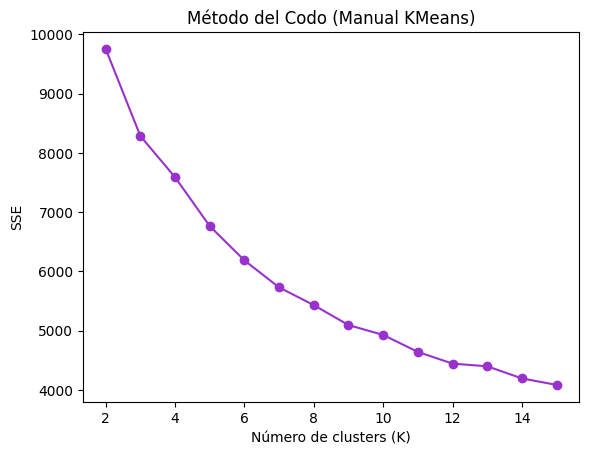

In [290]:
plt.plot(Ks, sse_manual, marker='o', color = "darkorchid")
plt.xlabel("Número de clusters (K)")
plt.ylabel("SSE")
plt.title("Método del Codo (Manual KMeans)")
plt.show()

Se puede visualizar una inflexión notoria en $k=5, 6$ así como en $k=8, 9$. Sin embargo, para mantener el número de clusters razonable y seguir teniendo una buena interpretabilidad se decide trabajar con $k=5$. 

### 4.2 Método de la silueta

Para ese método se utiliza la siguiente ecuación: 

$$
s(i) = \frac{b(i) -a(i)}{\max(a(i), b(i))}
$$

Donde $a(i)$ es la distancia promedio a puntos de su mismo cluster y $b(i)$ es la distancia promedio al cluster más cercano. Esta función se incluye a continuación. 

In [291]:
def silhouette_score_manual(X, labels):
    n = len(X)
    unique_labels = np.unique(labels)
    silhouette_vals = []

    for i in range(n):
        same_cluster = X[labels == labels[i]]
        other_clusters = [l for l in unique_labels if l != labels[i]]

        # a(i): distancia promedio dentro de su cluster
        if len(same_cluster) > 1:
            a = np.mean([euclidean_dist(X[i], x) for x in same_cluster if not np.array_equal(x, X[i])])
        else:
            a = 0

        # b(i): distancia al cluster más cercano
        b = float('inf')
        for label in other_clusters:
            cluster_points = X[labels == label]
            dist = np.mean([euclidean_dist(X[i], x) for x in cluster_points])
            b = min(b, dist)

        s = (b - a) / max(a, b) if max(a, b) != 0 else 0
        silhouette_vals.append(s)

    return np.mean(silhouette_vals)

Con base en ésta, se calcula el coeficiente de la silueta de cada uno de los valores de $k$ desde 2 a 15:

In [292]:
silhouette_scores_man = []
for k in Ks:
    kmeans = KMeans_Manual(K=k)
    labels = kmeans.predict(X)
    score = silhouette_score_manual(X, labels)
    silhouette_scores_man.append(score)

In [303]:
count = 2
for i in silhouette_scores_man: 
    print(f"Coeficiente Silueta para k={count}: {i}")
    count+=1

Coeficiente Silueta para k=2: 0.6215098934257066
Coeficiente Silueta para k=3: 0.6837082573916827
Coeficiente Silueta para k=4: 0.5693351183664266
Coeficiente Silueta para k=5: 0.5551273899040491
Coeficiente Silueta para k=6: 0.33231714845751054
Coeficiente Silueta para k=7: 0.45294698002365813
Coeficiente Silueta para k=8: 0.37602510743450485
Coeficiente Silueta para k=9: 0.4238492350442624
Coeficiente Silueta para k=10: 0.3218614753152767
Coeficiente Silueta para k=11: 0.32881562226564337
Coeficiente Silueta para k=12: 0.33635300287228304
Coeficiente Silueta para k=13: 0.31334616714314906
Coeficiente Silueta para k=14: 0.32189387019988
Coeficiente Silueta para k=15: 0.3277094735800829


Y finalmente se grafican a continuación:

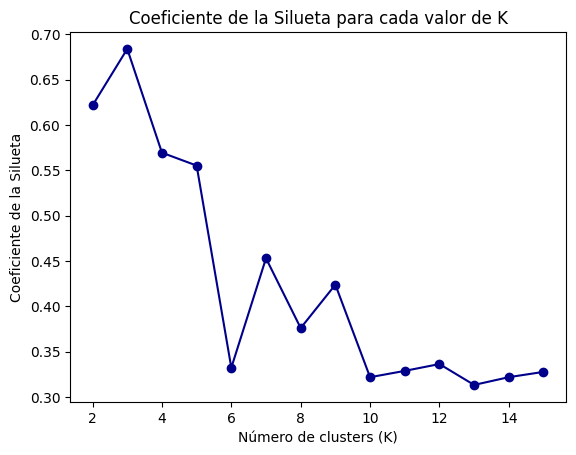

In [293]:
plt.plot(Ks, silhouette_scores_man, marker='o', color = "darkblue")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Coeficiente de la Silueta")
plt.title("Coeficiente de la Silueta para cada valor de K")
plt.show()

En este caso, el coeficiente silueta mayor es el de $k=3$ con un valor aproximado de 0.68, lo que indica que el punto se encuentra ligeramente bien agrupado y alejado de los demás. Para este caso, se prefiere trabajar a partir de $k=3$. 

## 5. Comparación con Scikit-Learn

En esta sección, se trabaja con el mismo dataset pero ahora comparando con el modelo de `KMeans` de la librería `scikit-learn`. 

In [294]:
sse_sci = []
all_labels = {}

for k in Ks:
    kmeans_scikit = KMeans(n_clusters=k, random_state=1, n_init=10)
    kmeans_scikit.fit(data)
    
    # guardar SSE
    sse_sci.append(kmeans_scikit.inertia_)
    
    # guardar labels
    all_labels[k] = kmeans_scikit.labels_
    print(f"Iteración para k={k}: SSE: {kmeans_scikit.inertia_}")

Iteración para k=2: SSE: 9754.773041553804
Iteración para k=3: SSE: 8284.754058014774
Iteración para k=4: SSE: 7419.398832385304
Iteración para k=5: SSE: 6763.663736638639
Iteración para k=6: SSE: 6185.242562267863
Iteración para k=7: SSE: 5638.544495430875
Iteración para k=8: SSE: 5174.739878961061
Iteración para k=9: SSE: 4798.464196239847
Iteración para k=10: SSE: 4539.7783835512555
Iteración para k=11: SSE: 4329.1858650902805
Iteración para k=12: SSE: 4069.6453320614723
Iteración para k=13: SSE: 3880.5467795290406
Iteración para k=14: SSE: 3733.931943305142
Iteración para k=15: SSE: 3588.093043384959


De primera instancia, se nota que el modelo de scikit-learn es significativamente más rápido que el manual, pues tomó un total de 1.6s mientras que el modelo manual tomó aproximadamente 1 minuto completo.  

Ahora, se calcula el coeficiente silueta para el modelo de KMeans de la librería: 

In [295]:
silhouette_scores_sci = []

for k in Ks:
    kmeans_scikit = KMeans(n_clusters=k, random_state=1, n_init=10)
    labels = kmeans_scikit.fit_predict(data)
    score = silhouette_score(data, labels)
    silhouette_scores_sci.append(score)
    print(f"Coeficiente Silueta para k={k}: {score}")

Coeficiente Silueta para k=2: 0.2610085569132981
Coeficiente Silueta para k=3: 0.22599803531157178
Coeficiente Silueta para k=4: 0.22004689925804213
Coeficiente Silueta para k=5: 0.20310217780436807
Coeficiente Silueta para k=6: 0.20240772791567538
Coeficiente Silueta para k=7: 0.20145544985626104
Coeficiente Silueta para k=8: 0.2067005907865849
Coeficiente Silueta para k=9: 0.21225635277708907
Coeficiente Silueta para k=10: 0.21157991351400135
Coeficiente Silueta para k=11: 0.2100631208694684
Coeficiente Silueta para k=12: 0.21890519258783683
Coeficiente Silueta para k=13: 0.22156386458672397
Coeficiente Silueta para k=14: 0.2230879169350563
Coeficiente Silueta para k=15: 0.2187529067986175



A continuación, se incluyen las gráficas de comparativa entre el modelo manual y el modelo de `scikit-learn`, con respecto al SSE y el Coeficiente Silueta. 

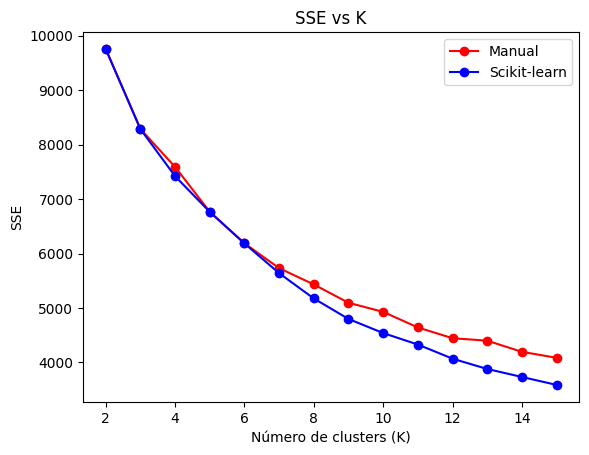

In [296]:
plt.plot(Ks, sse_manual, marker = 'o', color = "red", label ="Manual")
plt.plot(Ks, sse_sci, marker = 'o', color = "blue", label ="Scikit-learn")
plt.xlabel("Número de clusters (K)")
plt.ylabel("SSE")
plt.title("SSE vs K")
plt.legend()
plt.show()

En este gráfico se visualiza como la inercia en ambos modelos disminuye conforme aumenta el número de clusters. Se puede visualizar como tienen una tasa similar de decremento, sin embargo empiezan a separarse las gráficas a partir de $k=7$ y continúan aumentando la distancia entre sí. Para el modelo de `scikit-learn`, es más complicado identificar un codo, sin embargo se podría considerar $k=7$ como tal.  
A continuación se incluye el coeficiente silueta para ambos modelos: 

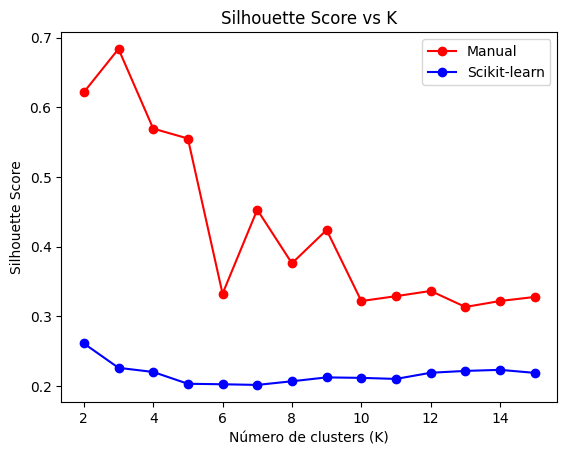

In [297]:
plt.plot(Ks, silhouette_scores_man, marker='o', color = "red", label ="Manual")
plt.plot(Ks, silhouette_scores_sci, marker='o', color = "blue", label ="Scikit-learn")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.legend()
plt.show()

En esta gráfica se visualiza una mayor dierencia entre ambos modelos, pues el modelo manual tiene un pico significativo en $k=3$, mientras que el modelo de `scikit-learn` tiene su "pico" en $k=2$. Sin embargo, para dicho modelo no se identifica una buena separación entre clusters, pues el máximo coeficiente es de aproximadamente 0.26. 

## 6. Aplicación de PCA

Dado que la dimensión del dataframe usado es de 6, se aplica PCA con apoyo de la librería de `scikit-learn`. El PCA busca nuevas variables o componentes principales que sean **combinaciones lineales** de las features y capturen la mayor varianza posible a través de ortogonalidad. Para esto se calcula la matriz de covarianza y después se obtiene el eigenvalor $\lambda$ para cada eigenvector que indica una dirección del componente por parte (PC). 

Se inicia separando en componentes de 2D y 3D el dataset y mostrando la varianza explicada en cada uno de los PCA: 

In [298]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(data)
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(data)

print("PCA 2D")
print(f"Varianza explicada por componente: {pca_2d.explained_variance_ratio_}")
print(f"Varianza total explicada: {sum(pca_2d.explained_variance_ratio_):.4f}\n")

print("PCA 3D")
print(f"Varianza explicada por componente: {pca_3d.explained_variance_ratio_}")
print(f"Varianza total explicada: {sum(pca_3d.explained_variance_ratio_):.4f}")

PCA 2D
Varianza explicada por componente: [0.34664042 0.21201744]
Varianza total explicada: 0.5587

PCA 3D
Varianza explicada por componente: [0.34664042 0.21201744 0.16647966]
Varianza total explicada: 0.7251


La varianza explicada indica qué proporción de la información original retiene cada reducción. Con 2 componentes se captura una parte representativa de la varianza total, suficiente para identificar visualmente la separación entre clusters. Con 3 componentes se captura aún más información y se puede explorar más a profunidad.  

A continuación se visualizan los clusters asignados por ambos modelos (Manual y Scikit-learn) proyectados sobre los componentes principales. Se usan colores distintos para cada cluster y markers diferenciados para los centroides. Se trabaja con $k=3$ (recomendado por el coeficiente silueta) como valor principal de comparación.  

Se inicia con la visualización 2D para ambos el modelo manual y el de `scikit-learn`

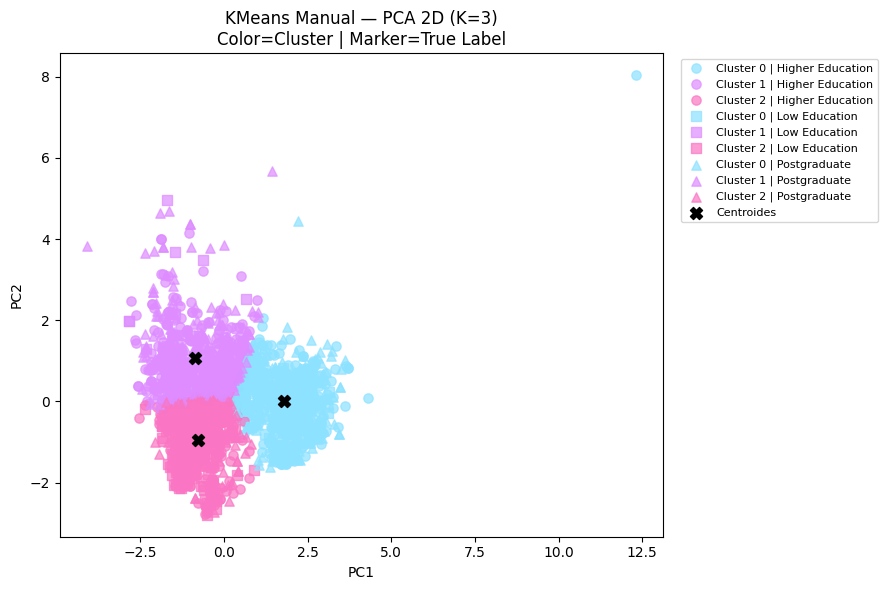

In [299]:
# Obtenemos las etiquetas del modelo manual para K=3
K_opt = 3

np.random.seed(42)
kmeans_manual = KMeans_Manual(K=K_opt, max_iters=100, plot_steps=False)
labels_manual = kmeans_manual.predict(data).astype(int)

# Color por cluster, marker por true label
cluster_colors  = ['#8ce2ff', '#de8cff', '#fa75c3']          # 3 clusters
true_label_markers = {
    'Higher Education': 'o',
    'Low Education'   : 's',
    'Postgraduate'    : '^'
}

fig, ax = plt.subplots(figsize=(9, 6))

for tl_name, marker in true_label_markers.items():
    tl_mask = true_label_names == tl_name
    for cluster_id in range(K_opt):
        cl_mask = labels_manual == cluster_id
        mask = tl_mask & cl_mask
        if mask.sum() == 0:
            continue
        ax.scatter(
            X_pca_2d[mask, 0], X_pca_2d[mask, 1],
            c=cluster_colors[cluster_id],
            marker=marker,
            s=45, alpha=0.7,
            label=f'Cluster {cluster_id} | {tl_name}'
        )

# Centroides proyectados en 2D
centroids_2d = pca_2d.transform(np.array(kmeans_manual.centroids))
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           marker='X', s=75, c='black', zorder=5, label='Centroides')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'KMeans Manual — PCA 2D (K={K_opt})\nColor=Cluster | Marker=True Label')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

A continuación, se encuentra la misma gráfica de 2D para KMeans de `scikit-learn`. 

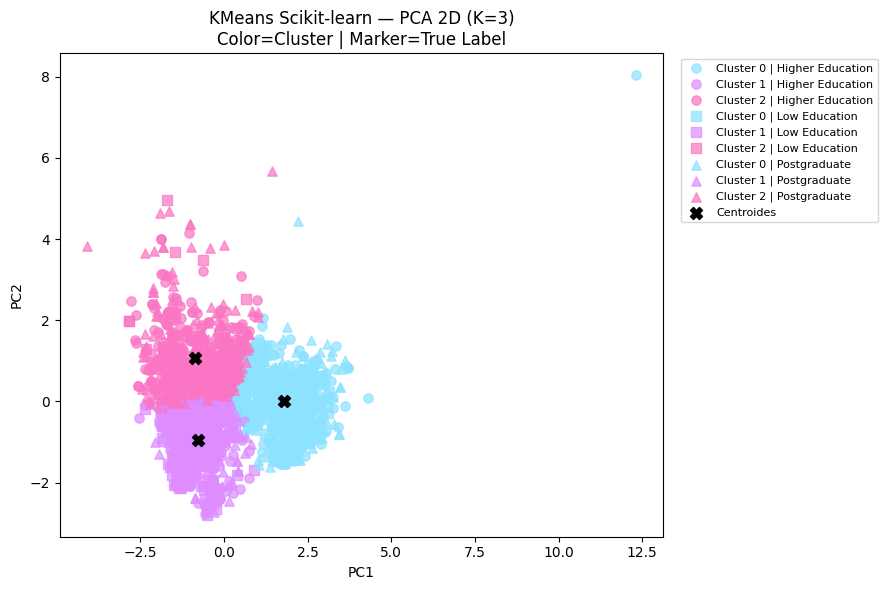

In [300]:
kmeans_sk = KMeans(n_clusters=K_opt, random_state=42, n_init=10)
labels_sk = kmeans_sk.fit_predict(data)

fig, ax = plt.subplots(figsize=(9, 6))

for tl_name, marker in true_label_markers.items():
    tl_mask = true_label_names == tl_name
    for cluster_id in range(K_opt):
        cl_mask = labels_sk == cluster_id
        mask = tl_mask & cl_mask
        if mask.sum() == 0:
            continue
        ax.scatter(
            X_pca_2d[mask, 0], X_pca_2d[mask, 1],
            c=cluster_colors[cluster_id],
            marker=marker,
            s=45, alpha=0.7,
            label=f'Cluster {cluster_id} | {tl_name}'
        )

# Centroides proyectados en 2D
centroids_sk_2d = pca_2d.transform(kmeans_sk.cluster_centers_)
ax.scatter(centroids_sk_2d[:, 0], centroids_sk_2d[:, 1],
           marker='X', s=75, c='black', zorder=5, label='Centroides')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'KMeans Scikit-learn — PCA 2D (K={K_opt})\nColor=Cluster | Marker=True Label')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

En las gráficas 2D se puede observar cómo los clusters (colores) no coinciden perfectamente con los true labels (markers). Esto es esperado: K-Means agrupa por similitud en las features numéricas (ingreso, gasto, edad…), mientras que los true labels reflejan el nivel educativo. La mezcla de markers dentro de un mismo color revela qué tan bien o mal el modelo captura la segmentación real por educación.  

Finalmente, se muestran las mismas gráficas pero para las 3 dimensiones. A continuación se visualiza el PCA para el modelo Manual de KMeans. Para visualizar en 3D se hace uso de las librerías `mpl_toolkids.mplot3d` y  `plotly` para poder tener una visualización más interactiva. 

In [301]:
# Mapeo de markers Plotly por true label
plotly_symbols = {
    'Higher Education': 'circle',
    'Low Education'   : 'square',
    'Postgraduate'    : 'diamond'
}

cluster_colors_plotly =  ['#8ce2ff', '#de8cff', '#fa75c3']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

fig = go.Figure()

for tl_name, symbol in plotly_symbols.items():
    tl_mask = true_label_names == tl_name
    for cluster_id in range(K_opt):
        cl_mask = labels_manual == cluster_id
        mask = tl_mask & cl_mask
        if mask.sum() == 0:
            continue
        fig.add_trace(go.Scatter3d(
            x=X_pca_3d[mask, 0],
            y=X_pca_3d[mask, 1],
            z=X_pca_3d[mask, 2],
            mode='markers',
            marker=dict(
                size=4,
                color=cluster_colors_plotly[cluster_id],
                symbol=symbol,
                opacity=0.75,
                line=dict(width=0.3, color='white')
            ),
            name=f'Cluster {cluster_id} | {tl_name}',
            legendgroup=f'{cluster_id}_{tl_name}'
        ))

# Centroides
centroids_3d = pca_3d.transform(np.array(kmeans_manual.centroids))
fig.add_trace(go.Scatter3d(
    x=centroids_3d[:, 0],
    y=centroids_3d[:, 1],
    z=centroids_3d[:, 2],
    mode='markers',
    marker=dict(size=5, color='black', symbol='x', line=dict(width=2, color='black')),
    name='Centroides'
))

fig.update_layout(
    title=dict(text=f'KMeans Manual — PCA 3D interactivo (K={K_opt})<br>'
                    '<sup>Color = Cluster | Marker = True Label (educación)</sup>',
               x=0.5),
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    legend=dict(itemsizing='constant', font=dict(size=11)),
    margin=dict(l=0, r=0, b=0, t=60),
    height=650
)

fig.show()

A continuación se muestra la visualización para 3D del modelo de `scikit-learn`:

In [302]:
fig = go.Figure()

for tl_name, symbol in plotly_symbols.items():
    tl_mask = true_label_names == tl_name
    for cluster_id in range(K_opt):
        cl_mask = labels_sk == cluster_id
        mask = tl_mask & cl_mask
        if mask.sum() == 0:
            continue
        fig.add_trace(go.Scatter3d(
            x=X_pca_3d[mask, 0],
            y=X_pca_3d[mask, 1],
            z=X_pca_3d[mask, 2],
            mode='markers',
            marker=dict(
                size=4,
                color=cluster_colors_plotly[cluster_id],
                symbol=symbol,
                opacity=0.75,
                line=dict(width=0.3, color='white')
            ),
            name=f'Cluster {cluster_id} | {tl_name}',
            legendgroup=f'{cluster_id}_{tl_name}'
        ))

# Centroides
centroids_sk_3d = pca_3d.transform(kmeans_sk.cluster_centers_)
fig.add_trace(go.Scatter3d(
    x=centroids_sk_3d[:, 0],
    y=centroids_sk_3d[:, 1],
    z=centroids_sk_3d[:, 2],
    mode='markers',
    marker=dict(size=5, color='black', symbol='x', line=dict(width=2, color='black')),
    name='Centroides'
))

fig.update_layout(
    title=dict(text=f'KMeans Scikit-learn — PCA 3D interactivo (K={K_opt})<br>'
                    '<sup>Color = Cluster | Marker = True Label (educación)</sup>',
               x=0.5),
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    legend=dict(itemsizing='constant', font=dict(size=11)),
    margin=dict(l=0, r=0, b=0, t=60),
    height=650
)

fig.show()

La visualización 3D confirma la estructura identificada en 2D y permite apreciar mejor la separación de los clusters en profundidad. Ambos modelos muestran una distribución similar de los puntos, con diferencias menores en la asignación de puntos fronterizos, lo que sugiere que el modelo manual logra una convergencia comparable a la implementación optimizada de `scikit-learn`.